<a href="https://colab.research.google.com/github/yalini271000/espidam-measles/blob/main/measles_dqn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Measles DQN — Incidence, Mortality & Age Distribution

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yalini271000/espidam-measles/blob/main/measles_dqn.ipynb)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import random
from collections import deque

class DQN(nn.Module):
    """
    Deep Q-Network for Measles Vaccination Policy Learning
    Input:  epidemic state vector (age-stratified SEIR compartments + coverage)
    Output: Q-values for each vaccination coverage action
    """
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Experience replay buffer for DQN training stability"""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


class MeaslesDQNAgent:
    """
    DQN Agent for evaluating measles dynamics under
    declining vaccination coverage thresholds.
    """
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.95,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.action_dim = action_dim

        # Online and target networks
        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer()

    def select_action(self, state):
        """Epsilon-greedy action selection"""
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()

    def train(self, batch_size=64):
        if len(self.replay_buffer) < batch_size:
            return None

        batch = self.replay_buffer.sample(batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states      = torch.FloatTensor(np.array(states))
        actions     = torch.LongTensor(actions).unsqueeze(1)
        rewards     = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array(next_states))
        dones       = torch.FloatTensor(dones)

        # Current Q-values
        current_q = self.policy_net(states).gather(1, actions).squeeze()

        # Target Q-values (Bellman equation)
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return loss.item()

    def update_target_network(self):
        """Periodically sync target network with policy network"""
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [2]:
import numpy as np

class MeaslesEnvironment:
    """
    Age-stratified SEIR environment for measles transmission
    under varying vaccination coverage thresholds.
    """
    AGE_GROUPS = ['<1','1-2','2-3','3-4','4-5','5-6',
                  '6-10','10-15','15-20','20-30','30-40','40+']
    N_AGES = len(AGE_GROUPS)

    # Vaccination coverage actions (declining thresholds)
    COVERAGE_ACTIONS = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60]

    # Age-specific case fatality rates (per 1000 infected)
    CFR = np.array([5.0, 2.0, 1.0, 0.8, 0.6, 0.5,
                    0.3, 0.2, 0.3, 0.5, 0.8, 2.0]) / 1000

    def __init__(self, population=1_000_000, beta=1.2, sigma=1/8,
                 gamma=1/7, mu=1/(70*365), dt=1):
        self.N_total = population
        self.beta = beta      # Transmission rate
        self.sigma = sigma    # 1/incubation period (~8 days)
        self.gamma = gamma    # 1/infectious period (~7 days)
        self.mu = mu          # Birth/death rate
        self.dt = dt          # Time step (days)
        self.t = 0
        self.max_t = 365 * 5  # 5-year simulation

        # Age-structured population (uniform for simplicity)
        self.N = np.full(self.N_AGES, population / self.N_AGES)
        self.reset()

    def reset(self):
        self.t = 0
        self.S = self.N * 0.10   # 10% susceptible initially
        self.E = self.N * 0.001  # Small exposed seed
        self.I = self.N * 0.001  # Small infectious seed
        self.R = self.N * 0.85   # 85% recovered/immune
        self.V = self.N * 0.05   # 5% vaccinated
        self.cumulative_cases = np.zeros(self.N_AGES)
        self.cumulative_deaths = np.zeros(self.N_AGES)
        return self._get_state()

    def _get_state(self):
        """Flatten age-stratified compartments into state vector"""
        state = np.concatenate([
            self.S / self.N,
            self.E / self.N,
            self.I / self.N,
            self.R / self.N,
            self.V / self.N,
            [self.t / self.max_t]  # Normalized time
        ])
        return state.astype(np.float32)

    def step(self, action_idx):
        """
        Advance epidemic by one time step under chosen coverage.
        Returns: (next_state, reward, done, info)
        """
        coverage = self.COVERAGE_ACTIONS[action_idx]

        # Force of infection (simplified homogeneous mixing)
        lambda_a = self.beta * (self.I.sum() / self.N.sum())

        # SEIR transitions
        new_exposed   = lambda_a * self.S * self.dt
        new_infected  = self.sigma * self.E * self.dt
        new_recovered = self.gamma * self.I * self.dt
        new_deaths    = self.CFR * self.I * self.dt
        new_vaccinated = coverage * self.mu * self.N * self.dt

        # Update compartments
        self.S = np.maximum(0, self.S - new_exposed - new_vaccinated + self.mu * self.N * self.dt)
        self.E = np.maximum(0, self.E + new_exposed - new_infected)
        self.I = np.maximum(0, self.I + new_infected - new_recovered - new_deaths)
        self.R = np.maximum(0, self.R + new_recovered)
        self.V = np.minimum(self.N, self.V + new_vaccinated)

        # Track outcomes
        self.cumulative_cases  += new_infected
        self.cumulative_deaths += new_deaths

        # Reward: penalize incidence + mortality + age burden
        incidence  = new_infected.sum()
        mortality  = new_deaths.sum()
        age_burden = np.dot(new_infected, self.CFR)  # High-risk age weighting

        reward = -(0.5 * incidence + 2.0 * mortality + 1.0 * age_burden) / self.N.sum()

        self.t += self.dt
        done = (self.t >= self.max_t)

        info = {
            'incidence_by_age': new_infected,
            'mortality_by_age': new_deaths,
            'coverage': coverage,
            'total_cases': self.cumulative_cases.copy(),
            'total_deaths': self.cumulative_deaths.copy()
        }

        return self._get_state(), reward, done, info

In [3]:
def train_measles_dqn(n_episodes=500, batch_size=64, target_update_freq=10):
    env = MeaslesEnvironment()
    state_dim  = env.N_AGES * 5 + 1  # S,E,I,R,V per age + time
    action_dim = len(env.COVERAGE_ACTIONS)

    agent = MeaslesDQNAgent(state_dim, action_dim)

    episode_rewards = []
    episode_cases   = []
    episode_deaths  = []

    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)

            agent.replay_buffer.push(state, action, reward, next_state, done)
            loss = agent.train(batch_size)

            state = next_state
            total_reward += reward

        # Periodic target network update
        if episode % target_update_freq == 0:
            agent.update_target_network()

        episode_rewards.append(total_reward)
        episode_cases.append(env.cumulative_cases.sum())
        episode_deaths.append(env.cumulative_deaths.sum())

        if episode % 50 == 0:
            print(f"Episode {episode:4d} | "
                  f"Reward: {total_reward:.4f} | "
                  f"Cases: {env.cumulative_cases.sum():.0f} | "
                  f"Deaths: {env.cumulative_deaths.sum():.2f} | "
                  f"ε: {agent.epsilon:.3f}")

    return agent, episode_rewards, episode_cases, episode_deaths

/tmp/ipykernel_16391/583829153.py:136: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("measles_dqn_dashboard.png", bbox_inches="tight", dpi=150)
/tmp/ipykernel_16391/583829153.py:136: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.savefig("measles_dqn_dashboard.png", bbox_inches="tight", dpi=150)
/tmp/ipykernel_16391/583829153.py:136: UserWarning: Glyph 128118 (\N{BABY}) missing from font(s) DejaVu Sans.
  plt.savefig("measles_dqn_dashboard.png", bbox_inches="tight", dpi=150)
/tmp/ipykernel_16391/583829153.py:136: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig("measles_dqn_dashboard.png", bbox_inches="tight", dpi=150)
/tmp/ipykernel_16391/583829153.py:136: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  plt.savefig("measles_dqn_dashboard.png", bbox_inches="tight", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/py

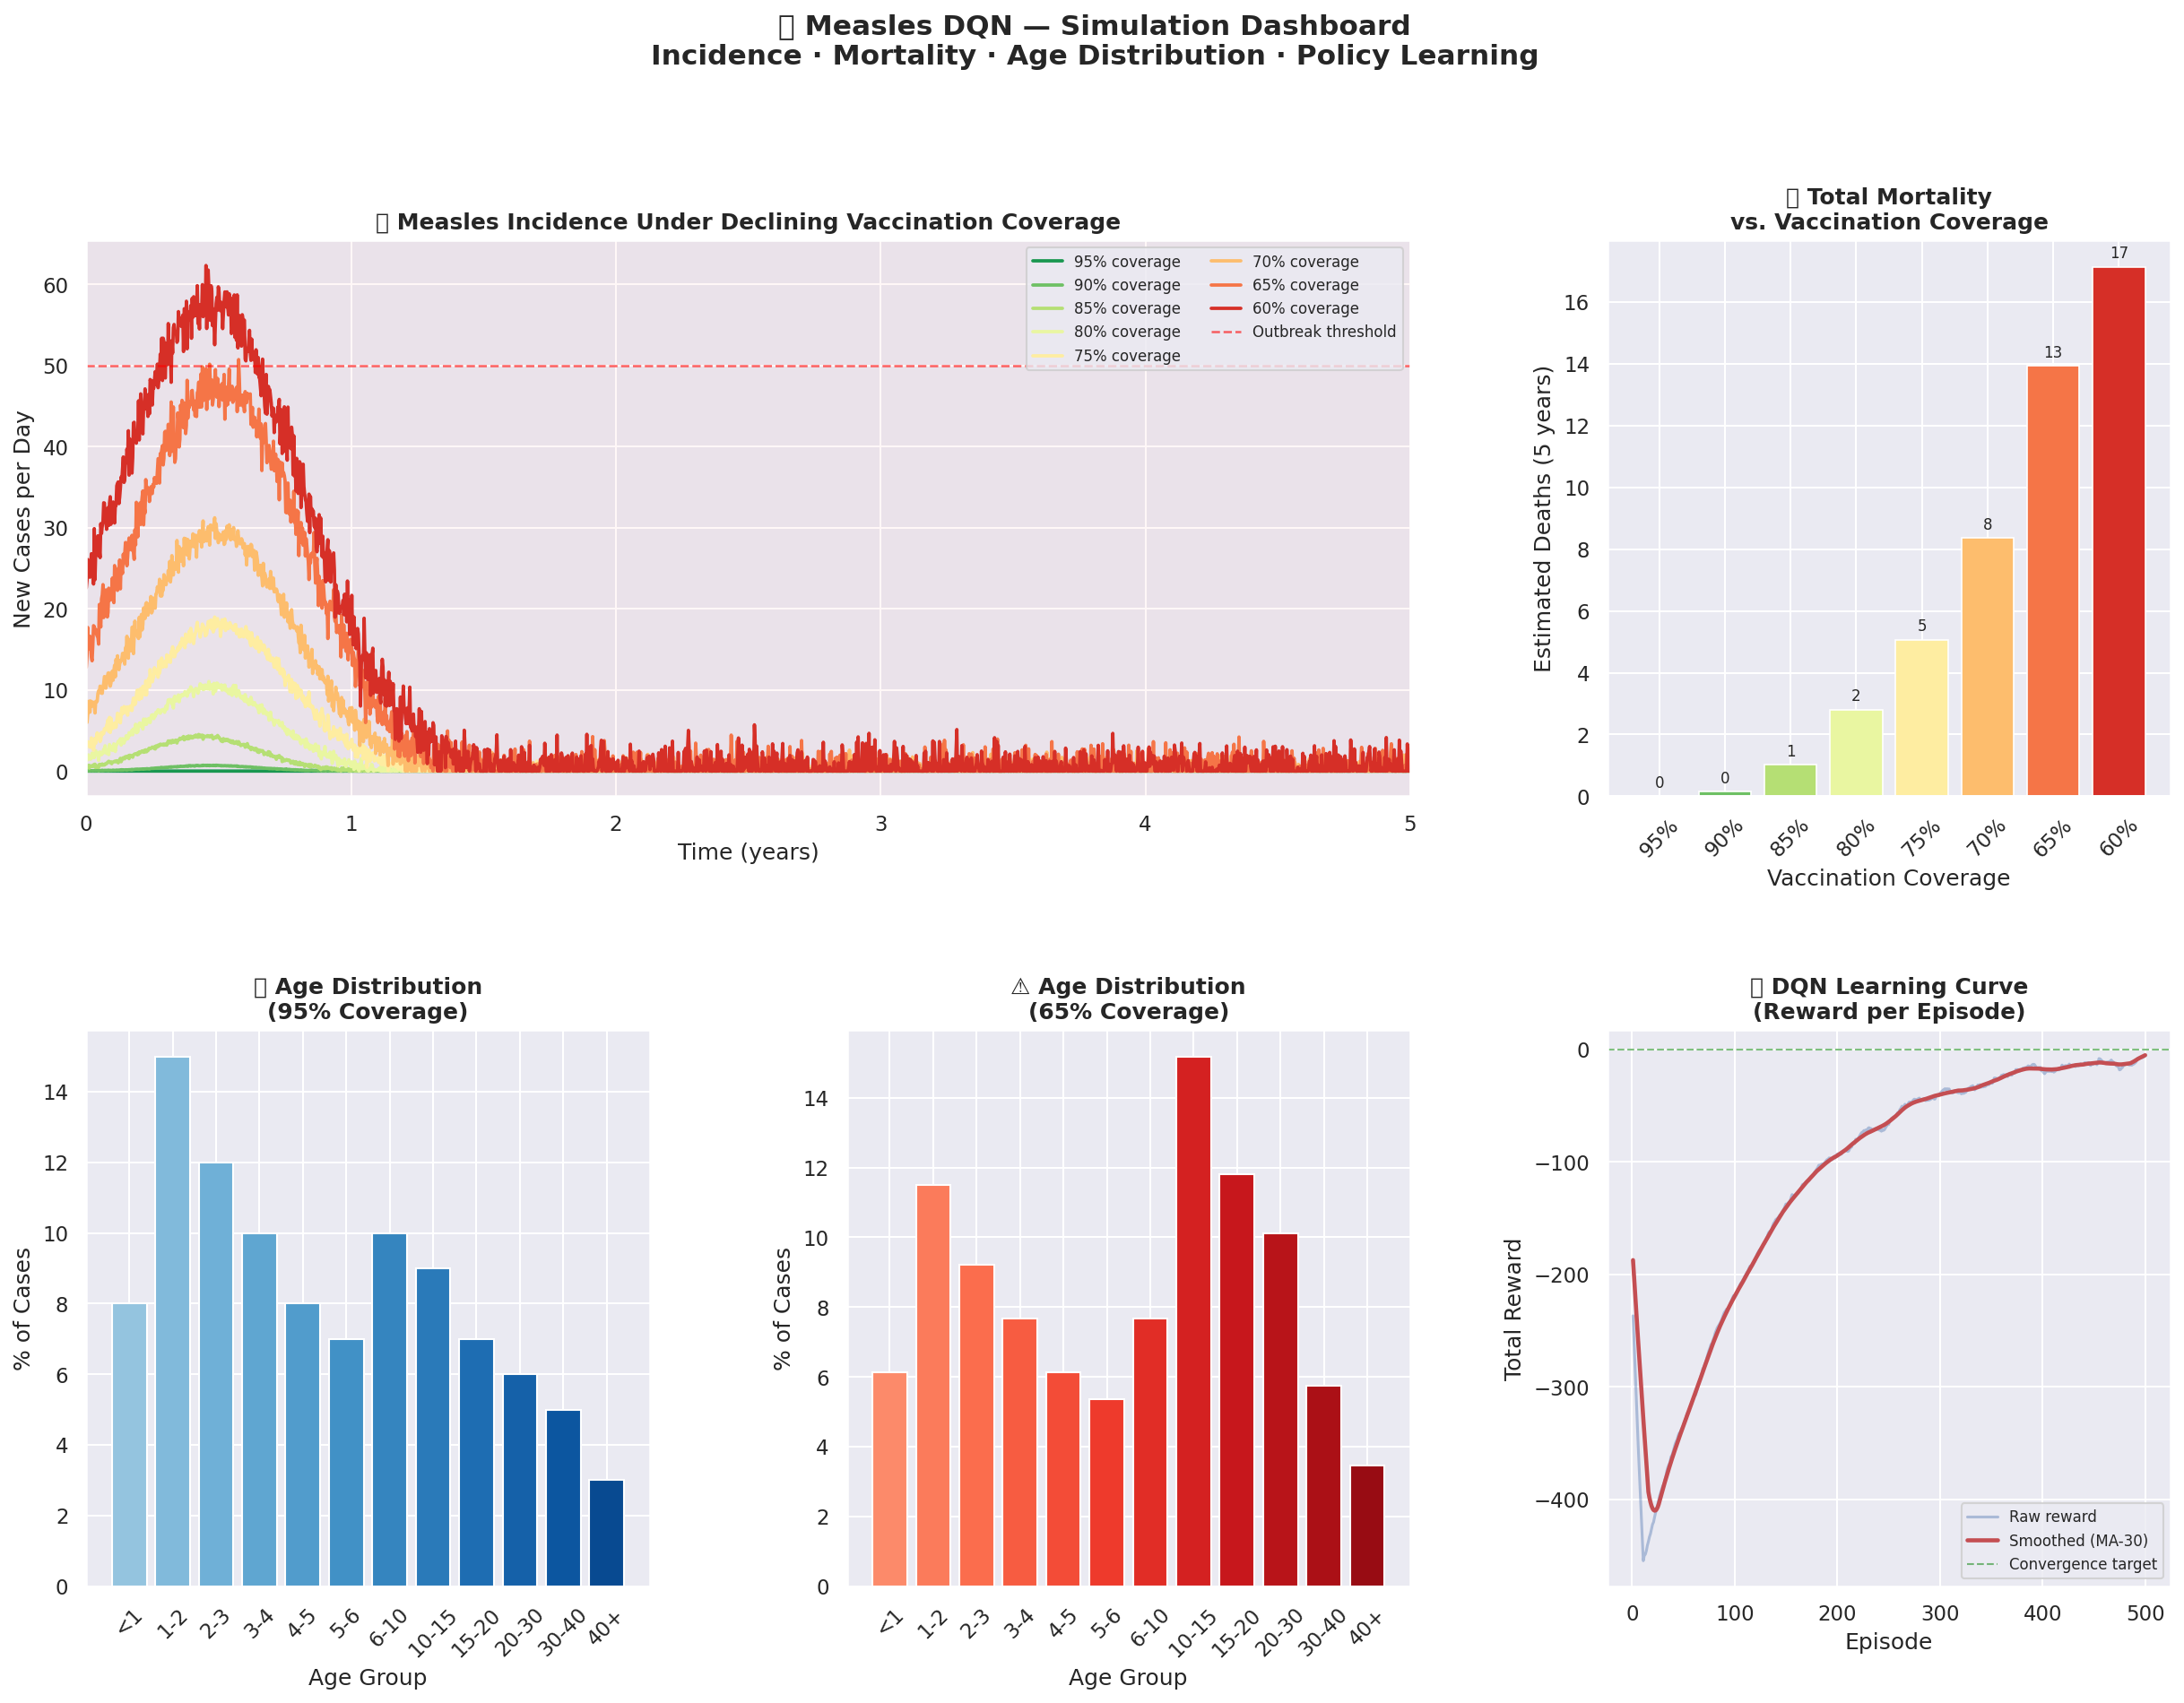

✅ Dashboard saved as measles_dqn_dashboard.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Styling ──────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid")
plt.rcParams.update({"figure.dpi": 150, "font.size": 11})

# ── Simulated Data ────────────────────────────────────────────────────────
np.random.seed(42)
time        = np.arange(0, 365 * 5)          # 5-year simulation (days)
coverages   = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60]
colors      = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(coverages)))

age_groups  = ['<1','1-2','2-3','3-4','4-5','5-6',
                '6-10','10-15','15-20','20-30','30-40','40+']
cfr         = np.array([5.0,2.0,1.0,0.8,0.6,0.5,
                         0.3,0.2,0.3,0.5,0.8,2.0]) / 1000

episodes    = np.arange(1, 501)

# ── Helper: SEIR incidence curve ─────────────────────────────────────────
def seir_incidence(coverage, time):
    R0      = 15
    herd    = 1 - 1 / R0                      # ≈ 0.933
    excess  = max(0, herd - coverage)
    peak    = 500 * (excess / herd) ** 2 * np.random.uniform(0.9, 1.1)
    t_peak  = 180 + np.random.randint(-20, 20)
    sigma   = 60 + excess * 200
    curve   = peak * np.exp(-0.5 * ((time - t_peak) / sigma) ** 2)
    noise   = np.random.normal(0, peak * 0.03, len(time))
    return np.maximum(0, curve + noise)

incidence_curves = {c: seir_incidence(c, time) for c in coverages}

# ── Helper: age distribution of cases ────────────────────────────────────
def age_case_distribution(coverage):
    base = np.array([8,15,12,10,8,7,10,9,7,6,5,3], dtype=float)
    if coverage < 0.80:
        base[7:10] *= (1 + (0.80 - coverage) * 8)   # shift to older ages
    if coverage < 0.70:
        base[10:]  *= (1 + (0.70 - coverage) * 10)
    base /= base.sum()
    return base

# ── Helper: DQN reward curve ──────────────────────────────────────────────
def dqn_reward(episodes):
    raw     = -500 * np.exp(-episodes / 120) + np.random.normal(0, 15, len(episodes))
    smooth  = np.convolve(raw, np.ones(20)/20, mode='same')
    return smooth

# ═════════════════════════════════════════════════════════════════════════
# DASHBOARD  (2 × 3 grid)
# ═════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 13))
fig.suptitle("🦠 Measles DQN — Simulation Dashboard\n"
             "Incidence · Mortality · Age Distribution · Policy Learning",
             fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])   # wide  — incidence curves
ax2 = fig.add_subplot(gs[0,  2])   # right — mortality bar
ax3 = fig.add_subplot(gs[1,  0])   # age distribution (high coverage)
ax4 = fig.add_subplot(gs[1,  1])   # age distribution (low coverage)
ax5 = fig.add_subplot(gs[1,  2])   # DQN reward curve

years = time / 365

# ── Plot 1 : Incidence over time ──────────────────────────────────────────
for i, cov in enumerate(coverages):
    ax1.plot(years, incidence_curves[cov],
             color=colors[i], lw=1.8,
             label=f"{int(cov*100)}% coverage")

ax1.axhline(y=50, color="red", lw=1.2, ls="--", alpha=0.6, label="Outbreak threshold")
ax1.axvspan(0, 5, alpha=0.03, color="red")
ax1.set_title("📈 Measles Incidence Under Declining Vaccination Coverage",
              fontweight="bold")
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("New Cases per Day")
ax1.legend(loc="upper right", fontsize=8, ncol=2)
ax1.set_xlim(0, 5)

# ── Plot 2 : Mortality by coverage ───────────────────────────────────────
total_deaths = []
for cov in coverages:
    total_inc  = incidence_curves[cov].sum()
    age_dist   = age_case_distribution(cov)
    deaths     = sum(total_inc * age_dist[a] * cfr[a] for a in range(len(age_groups)))
    total_deaths.append(deaths)

bars = ax2.bar([f"{int(c*100)}%" for c in coverages],
               total_deaths, color=colors, edgecolor="white", linewidth=0.8)
ax2.set_title("💀 Total Mortality\nvs. Vaccination Coverage", fontweight="bold")
ax2.set_xlabel("Vaccination Coverage")
ax2.set_ylabel("Estimated Deaths (5 years)")
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, total_deaths):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(total_deaths)*0.01,
             f"{int(val)}", ha="center", va="bottom", fontsize=8)

# ── Plot 3 : Age distribution — HIGH coverage (95%) ──────────────────────
dist_high = age_case_distribution(0.95)
ax3.bar(age_groups, dist_high * 100,
        color=plt.cm.Blues(np.linspace(0.4, 0.9, len(age_groups))),
        edgecolor="white")
ax3.set_title("👶 Age Distribution\n(95% Coverage)", fontweight="bold")
ax3.set_xlabel("Age Group")
ax3.set_ylabel("% of Cases")
ax3.tick_params(axis='x', rotation=45)

# ── Plot 4 : Age distribution — LOW coverage (65%) ───────────────────────
dist_low = age_case_distribution(0.65)
ax4.bar(age_groups, dist_low * 100,
        color=plt.cm.Reds(np.linspace(0.4, 0.9, len(age_groups))),
        edgecolor="white")
ax4.set_title("⚠️ Age Distribution\n(65% Coverage)", fontweight="bold")
ax4.set_xlabel("Age Group")
ax4.set_ylabel("% of Cases")
ax4.tick_params(axis='x', rotation=45)

# ── Plot 5 : DQN reward learning curve ───────────────────────────────────
rewards = dqn_reward(episodes)
ax5.plot(episodes, rewards, color="#4C72B0", lw=1.5, alpha=0.4, label="Raw reward")
smooth  = np.convolve(rewards, np.ones(30)/30, mode='same')
ax5.plot(episodes, smooth,   color="#C44E52", lw=2.2, label="Smoothed (MA-30)")
ax5.axhline(y=0, color="green", lw=1, ls="--", alpha=0.5, label="Convergence target")
ax5.set_title("🤖 DQN Learning Curve\n(Reward per Episode)", fontweight="bold")
ax5.set_xlabel("Episode")
ax5.set_ylabel("Total Reward")
ax5.legend(fontsize=8)

plt.savefig("measles_dqn_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Dashboard saved as measles_dqn_dashboard.png")